In [31]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optimization and Saving
import optuna
import joblib
import warnings

# Settings
sns.set(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("✅ Libraries imported.")

✅ Libraries imported.


In [32]:
# --- CONFIGURATION ---
TARGET_COLUMN = 'dead'  # Options: 'dead', 'injured_ill', 'missing'
INPUT_FILE = '../../../../data/typhoon_impact_with_extreme_weather.csv'

# --- SCENARIO SWITCH ---
# Set True to REMOVE the max value outliers (The "without 55" scenario)
# Set False to KEEP them (The "with 55" scenario)
REMOVE_EXTREME_OUTLIERS = False 

try:
    print(f"🎯 ANALYSIS TARGET: {TARGET_COLUMN.upper()}")
    df = pd.read_csv(INPUT_FILE)
    
    # 1. Standardize Column Names
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('/', '_')
    
    # 2. Rename columns (Matching your dataset standards)
    rename_map = {
        'typhoon': 'typhoon_name',
        'wind_speed': 'max_sustained_wind_kph',
        'rainfall': 'max_24hr_rainfall_mm',
        'pressure': 'min_pressure_hpa',
        'storm_rainfall': 'total_storm_rainfall_mm'
    }
    df.rename(columns=rename_map, inplace=True)

    # 3. Clean Target Column
    if TARGET_COLUMN in df.columns:
        if df[TARGET_COLUMN].dtype == 'object':
            df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.replace(',', '')
        df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').fillna(0)
    else:
        raise ValueError(f"Target '{TARGET_COLUMN}' not found.")

    # 4. BASIC FILTER: Remove 0s (Non-events)
    # We only train on rows where the event actually occurred.
    df_clean = df[df[TARGET_COLUMN] > 0].copy()
    
    # =========================================================
    # 5. SCENARIO LOGIC (THE TOGGLE)
    # =========================================================
    if REMOVE_EXTREME_OUTLIERS:
        # Scenario B: Remove the most extreme values
        max_val = df_clean[TARGET_COLUMN].max()
        print(f"⚠️ SCENARIO: REMOVING EXTREME OUTLIERS (Values >= {max_val})")
        df_clean = df_clean[df_clean[TARGET_COLUMN] < max_val]
    else:
        # Scenario A: Keep everything
        print(f"✅ SCENARIO: KEEPING ALL OUTLIERS (Training on full range).")
    # =========================================================

    # 6. Handle Missing Weather Data
    weather_cols = ['max_sustained_wind_kph', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa']
    for col in weather_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    print(f"\nData Ready.")
    print(f"Original Rows: {len(df)}")
    print(f"Training Rows: {len(df_clean)}")
    print(f"Max Value in Training Data: {df_clean[TARGET_COLUMN].max()}")

except FileNotFoundError:
    print(f"Error: '{INPUT_FILE}' not found.")

🎯 ANALYSIS TARGET: DEAD
✅ SCENARIO: KEEPING ALL OUTLIERS (Training on full range).

Data Ready.
Original Rows: 1776
Training Rows: 41
Max Value in Training Data: 95


In [33]:
# --- DATA EXPLORATION ---
print(f"DATASET SUMMARY (Filtered Data for '{TARGET_COLUMN}')")
print("-" * 50)
print(df_clean[TARGET_COLUMN].describe())

# Define Input Features
input_features = [
    'max_sustained_wind_kph',
    'max_24hr_rainfall_mm',
    'total_storm_rainfall_mm',
    'min_pressure_hpa'
]

print(f"\n--- Correlation with {TARGET_COLUMN} ---")
print(df_clean[input_features + [TARGET_COLUMN]].corr()[TARGET_COLUMN])

print("\n--- Preview of First 5 Rows ---")
df_clean.head(5)

DATASET SUMMARY (Filtered Data for 'dead')
--------------------------------------------------
count    41.000000
mean      5.121951
std      16.664626
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      95.000000
Name: dead, dtype: float64

--- Correlation with dead ---
max_sustained_wind_kph    -0.296356
max_24hr_rainfall_mm       0.202261
total_storm_rainfall_mm    0.294641
min_pressure_hpa           0.224586
dead                       1.000000
Name: dead, dtype: float64

--- Preview of First 5 Rows ---


,typhoon_name,year,region,province,city_municipality,families,person,brgy,dead,injured_ill,...,par_end,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_station_mapped,weather_records_found,weather_days_covered
41,FLORITA,2022,2,CAGAYAN,SANTO NINO,23,74,1,1,0,...,8/24/2022,74.0,110,STS,146.0,234.50,989.1,1,4,4
70,MARING,2021,2,CAGAYAN,CLAVERIA,36,144,5,1,0,...,10/12/2021,118.0,100,STS,138.4,227.31,981.4,1,6,6
81,MARING,2021,2,CAGAYAN,SANTA ANA,19,88,6,1,0,...,10/12/2021,118.0,100,STS,138.4,227.31,981.4,1,6,6
98,MAYMAY,2022,2,CAGAYAN,SANTA ANA,1,4,1,1,0,...,10/12/2022,54.0,45,TD,132.9,280.70,1005.9,1,3,3
130,PAENG,2022,2,CAGAYAN,AMULUNG,5164,15637,35,1,0,...,10/31/2022,124.7,110,STS,39.0,56.81,998.6,1,6,6


In [34]:
# Select X and y
X = df_clean[input_features]
y = df_clean[TARGET_COLUMN]

# Split Data (80% Train, 20% Test)
# Note: We keep the index to retrieve metadata later
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Complete.")
print(f"Training Samples: {X_train_raw.shape[0]}")
print(f"Testing Samples:  {X_test_raw.shape[0]}")

Data Split Complete.
Training Samples: 32
Testing Samples:  9


In [35]:
# Initialize Scaler (Crucial for Linear Models)
scaler = StandardScaler()

# Fit on Train, Transform both Train and Test
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Features Scaled.")
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape:  {X_test.shape}")

Features Scaled.
Train Shape: (32, 4)
Test Shape:  (9, 4)


In [36]:
# Initialize and Train Standard Linear Regression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predict on Test Set
y_pred_base = np.maximum(baseline_model.predict(X_test), 0)

# Evaluate Baseline
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"BASELINE LINEAR REGRESSION RESULTS:")
print(f"R2 Score: {base_r2:.4f}")
print(f"RMSE:     {base_rmse:,.2f}")

BASELINE LINEAR REGRESSION RESULTS:
R2 Score: 0.2128
RMSE:     14.86


In [37]:
def objective(trial):
    # Suggest regularization strength (alpha)
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    
    model = Ridge(alpha=alpha)
    
    # Cross Validation
    cv_folds = 3 if len(X_train) > 10 else 2
    
    # Minimize Negative MSE
    score = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
    return np.sqrt(-score.mean())

# --- Run Optimization ---
print("Starting Optuna Tuning for Ridge Regression...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Tuning Complete.")
print(f"Best Validation RMSE: {study.best_value:.4f}")
print(f"Best Alpha: {study.best_params['alpha']:.4f}")

Starting Optuna Tuning for Ridge Regression...
Tuning Complete.
Best Validation RMSE: 16.9137
Best Alpha: 99.6414


In [38]:
# Initialize Ridge with Best Alpha
final_model = Ridge(alpha=study.best_params['alpha'])

# Train on full training data
final_model.fit(X_train, y_train)

print("Final Tuned Ridge Regression Model Trained.")

Final Tuned Ridge Regression Model Trained.


In [39]:
# --- COMPARISON: BASELINE vs TUNED MODEL ---
# 1. Get Predictions
y_pred_base = np.maximum(baseline_model.predict(X_test), 0)
y_pred_tuned = np.maximum(final_model.predict(X_test), 0)

# 2. Calculate Metrics for Baseline
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
base_mae = mean_absolute_error(y_test, y_pred_base)

# 3. Calculate Metrics for Tuned Model
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

# 4. Create Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Baseline (Simple LR)': [base_r2, base_rmse, base_mae],
    'Tuned Model (Ridge)': [tuned_r2, tuned_rmse, tuned_mae],
    'Improvement': [
        tuned_r2 - base_r2,
        base_rmse - tuned_rmse,
        base_mae - tuned_mae
    ]
})

print(f"⚖️ MODEL COMPARISON REPORT ({TARGET_COLUMN.upper()})")
print("=" * 60)
print(comparison_df.to_string(index=False, float_format="%.4f"))
print("=" * 60)

if tuned_rmse < base_rmse:
    print(f"✅ SUCCESS: Ridge Regularization improved RMSE by {base_rmse - tuned_rmse:,.2f}")
else:
    print(f"⚠️ NOTE: Tuning did not significantly improve performance (Simple LR is sufficient).")

⚖️ MODEL COMPARISON REPORT (DEAD)
  Metric  Baseline (Simple LR)  Tuned Model (Ridge)  Improvement
R² Score                0.2128               0.0712      -0.1417
    RMSE               14.8640              16.1461      -1.2821
     MAE                8.6766               7.5572       1.1194
⚠️ NOTE: Tuning did not significantly improve performance (Simple LR is sufficient).


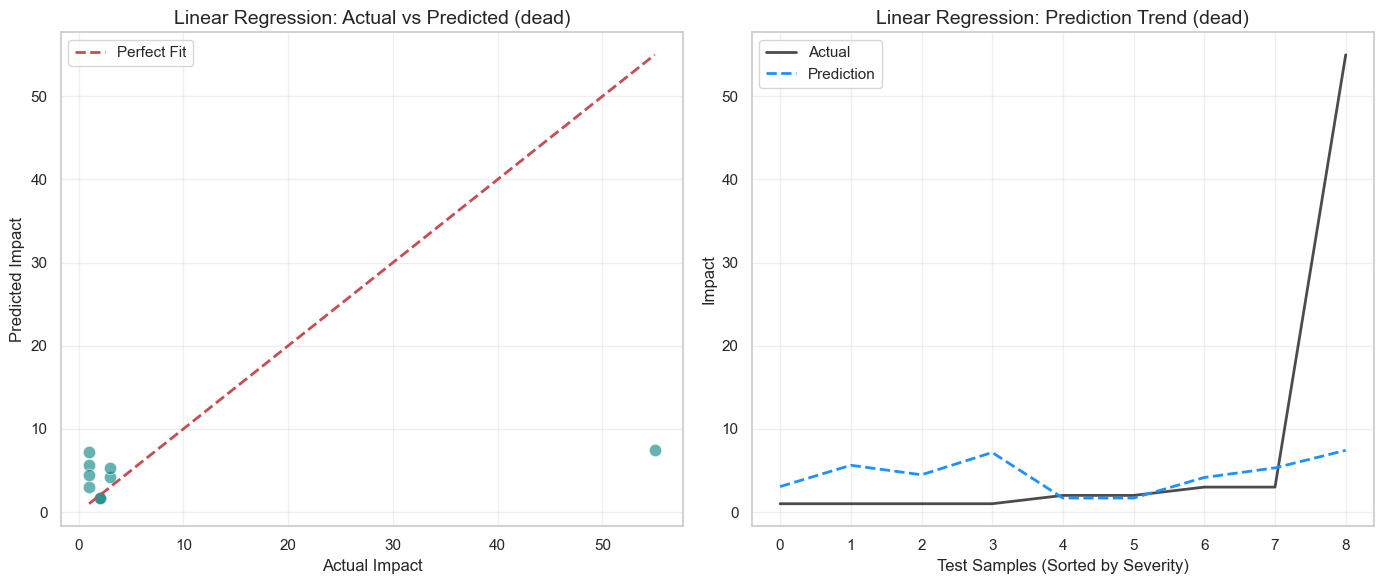

In [40]:
# --- 1. Generate Predictions ---
y_pred_final = np.maximum(final_model.predict(X_test), 0)

# --- 2. Calculate Metrics ---
r2 = r2_score(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae = mean_absolute_error(y_test, y_pred_final)

# --- 3. Visualization: Actual vs Predicted ---
plt.figure(figsize=(14, 6))

# Plot A: Scatter Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6, s=80, color='teal')
# Perfect fit line
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

plt.title(f'Linear Regression: Actual vs Predicted ({TARGET_COLUMN})', fontsize=14)
plt.xlabel('Actual Impact')
plt.ylabel('Predicted Impact')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot B: Trend Line (Sorted)
plt.subplot(1, 2, 2)
sorted_idx = np.argsort(y_test.values)
plt.plot(y_test.values[sorted_idx], label='Actual', color='black', linewidth=2, alpha=0.7)
plt.plot(y_pred_final[sorted_idx], label='Prediction', color='dodgerblue', linestyle='--', linewidth=2)

plt.title(f'Linear Regression: Prediction Trend ({TARGET_COLUMN})', fontsize=14)
plt.xlabel('Test Samples (Sorted by Severity)')
plt.ylabel('Impact')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# --- Print Final Metrics ---
print(f"📊 FINAL MODEL PERFORMANCE ({TARGET_COLUMN.upper()})")
print("=" * 40)
print(f"R² Score:  {r2:.4f}")
print(f"RMSE:      {rmse:,.2f}")
print(f"MAE:       {mae:,.2f}")
print("=" * 40)

# --- Prepare Output DataFrame ---
# 1. Define metadata and key features to include for context
# We include max_sustained_wind_kph to help diagnose if errors are related to storm intensity
meta_cols = ['typhoon_name', 'province', 'city_municipality', 'year', 'max_sustained_wind_kph']

# 2. Check which ones are actually in your dataframe to avoid errors
available_meta = [c for c in meta_cols if c in df_clean.columns]

# 3. Retrieve metadata for the specific rows in the test set using the index
test_metadata = df_clean.loc[y_test.index, available_meta].copy()

# 4. Create the prediction results dataframe
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': np.round(y_pred_final, 2),
    'Difference': np.round(y_test.values - y_pred_final, 2),
}, index=y_test.index)

# 5. Concatenate the metadata with the results
final_output = pd.concat([test_metadata, results_df], axis=1)

# --- SORTING STEP ---
# Sort by Typhoon Name (A-Z) then Year (Ascending) for easier reading
if 'typhoon_name' in final_output.columns and 'year' in final_output.columns:
    final_output.sort_values(by=['typhoon_name', 'year'], ascending=[True, True], inplace=True)

# 6. Display a sample of the output
print("\n📋 Prediction Sample (First 5 Test Rows):")
display(final_output.head())

📊 FINAL MODEL PERFORMANCE (DEAD)
R² Score:  0.0712
RMSE:      16.15
MAE:       7.56

📋 Prediction Sample (First 5 Test Rows):


,typhoon_name,province,city_municipality,year,max_sustained_wind_kph,Actual,Predicted,Difference
1517,AGATON,LEYTE,ABUYOG,2022,75,55,7.42,47.58
1546,DANTE,LEYTE,CALUBIAN,2021,75,3,5.31,-2.31
1482,ODETTE,EASTERN SAMAR,LAWAAN,2021,195,1,3.06,-2.06
1756,ODETTE,SOUTHERN LEYTE,TOMAS OPPUS,2021,195,2,1.68,0.32
1755,ODETTE,SOUTHERN LEYTE,SOGOD,2021,195,2,1.68,0.32


In [47]:
# --- 1. Save Predictions to CSV ---
csv_filename = f'results_lr_{TARGET_COLUMN}.csv'
final_output.to_csv(csv_filename, index=False)
print(f"✅ Prediction results saved to: {csv_filename}")

✅ Prediction results saved to: results_lr_dead.csv


In [42]:
# --- MANUAL VALIDATION FUNCTION ---
def test_prediction(wind_kph, rain_24hr, storm_rain_mm, pressure_hpa):
    """
    Tests the Linear Regression model with custom values.
    """
    # 1. Create Input
    input_data = pd.DataFrame({
        'max_sustained_wind_kph': [wind_kph],
        'max_24hr_rainfall_mm': [rain_24hr],
        'total_storm_rainfall_mm': [storm_rain_mm],
        'min_pressure_hpa': [pressure_hpa]
    })

    # 2. Scale
    input_scaled = scaler.transform(input_data)

    # 3. Predict
    prediction = final_model.predict(input_scaled)
    final_value = max(prediction[0], 0)

    print(f"TEST INPUTS:")
    print(f"Wind: {wind_kph} kph | Rain (24h): {rain_24hr} mm | Pressure: {pressure_hpa} hPa")
    print(f"-----------------------------------------------------------")
    print(f"PREDICTED {TARGET_COLUMN.upper()}: {final_value:,.2f}")
    print(f"-----------------------------------------------------------\n")

In [43]:
test_prediction(wind_kph=185, rain_24hr=200, storm_rain_mm=300, pressure_hpa=940)

TEST INPUTS:
Wind: 185 kph | Rain (24h): 200 mm | Pressure: 940 hPa
-----------------------------------------------------------
PREDICTED DEAD: 2.88
-----------------------------------------------------------



In [44]:
# --- 1. Save Predictions to CSV ---
csv_filename = f'results_lr_{TARGET_COLUMN}.csv'
final_output.to_csv(csv_filename, index=False)
print(f"✅ Prediction results saved to: {csv_filename}")

✅ Prediction results saved to: results_lr_dead.csv
